# ----- PART A - PYTHON CODING-----
# ----- Q3. FEATURE ENGINEERING AND REGRESSION PIPELINE-----

# --- Task 1. Data feature engineering

In [1]:
# Importing Liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# To load the dataset
df = pd.read_csv(r"D:\Richa\BITSOM\Assignments'\2511416_Deshmukh_Richa_Assignment_04\ml-assessment-Richa-Deshmukh\data\q3_retail_promotions.csv")

# To extract date , month and year from transaction_date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# to create dataframe for each month, year and day of week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek 
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# To display new sample of resulting dataframe
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# --- Task 2. Temporal train-test split

In [3]:
# Creating new data frame and storing sorted value by transaction_date
df = df.sort_values('transaction_date')

split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

# A time-based split preserves the chronological order of data and prevents data leakage. Using future data in training would lead to overly optimistic performance estimates. Random split breaks time dependency → leakage risk.

# --- Task 3. Preprossesing Pipeline

In [4]:
# Importing required functions
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# --- Task 4. Model training and evolution

In [5]:
# Importing required functions
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression model
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# To fit in the pipeline
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

# Random Forest model
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# To fit in the pipeline
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)

In [6]:
# Defining fuction to report RMSE and MAE on the test model
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

print("LR:", evaluate(y_test, pred_lr))
print("RF:", evaluate(y_test, pred_rf))

LR: (27.12145116489062, 21.052926674588388)
RF: (31.658897860633115, 24.904708333333335)


# RMSE penalizes larger errors more heavily, making it useful when large prediction errors are costly. MAE provides an average error magnitude, making it easier to interpret in business terms.

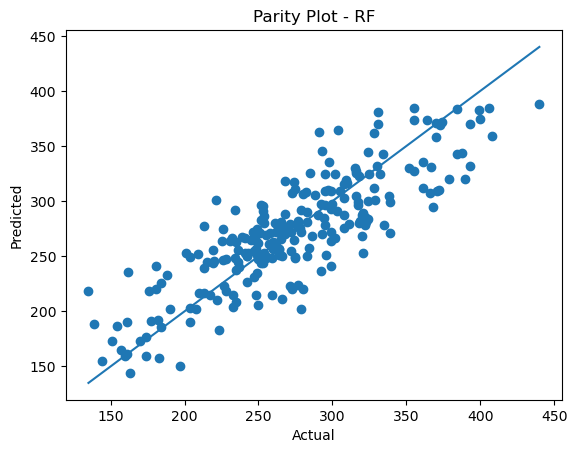

In [7]:
# To produce and display a parity plot (predicted vs actual items_sold) for each model, with a diagonal reference line
plt.scatter(y_test, pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot - RF")
plt.show()

In [8]:
# To print the feature importances from the Random Forest and identify the top 5 most influential features

model = pipe_rf.named_steps['model']
features = pipe_rf.named_steps['preprocessor'].get_feature_names_out()

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(5))

                     feature  importance
15     cat__store_size_small    0.183953
2           num__is_festival    0.174490
13  cat__location_type_urban    0.140494
6           num__day_of_week    0.087179
1            num__is_weekend    0.066870


# Feature importance indicates which variables have the greatest influence on predictions. Identifying top features helps in understanding key drivers of sales and supports better business decision-making.